In [ ]:
!pip install google-cloud-storage

In [ ]:
!pip install  tensorflow
!pip install scikit-learn

In [ ]:
!pip install numpy --upgrade
!pip install tensorflow --upgrade


In [1]:
from google.cloud import storage
import pandas as pd

# Inicializa el cliente de Google Cloud Storage
client = storage.Client()

bucket_name = 'unir-david-laura-metro'
folder_name = 'data/'

# Accede al bucket
bucket = client.get_bucket(bucket_name)

# Lista los archivos en la carpeta
blobs = bucket.list_blobs(prefix=folder_name)
for blob in blobs:
    print(blob.name)  # Muestra el nombre de los archivos


data/
data/DISTANCIAS.csv
data/OD.csv
data/df_afluencia_diaria.csv


In [2]:
# Cargar los tres datasets
DISTANCIAS = pd.read_csv('gs://unir-david-laura-metro/data/DISTANCIAS.csv', sep=';', encoding='ISO-8859-1')
OD = pd.read_csv('gs://unir-david-laura-metro/data/OD.csv', sep=';', encoding='ISO-8859-1')
DIARIO = pd.read_csv('gs://unir-david-laura-metro/data/df_afluencia_diaria.csv', sep=';', encoding='ISO-8859-1')

# Ver las primeras filas de los datasets
print(DISTANCIAS.head())
print(OD.head())
print(DIARIO.head())


  linea_origen estacion_origen linea_destino estacion_destino    distancia
0            A          Niquía             A            Bello  1341,801937
1            A           Bello             A           Madera   1583,71928
2            A          Madera             A          Acevedo  1798,041307
3            A         Acevedo             A    Tricentenario  1264,219197
4            A   Tricentenario             A           Caribe  1423,693274
   fecha_uso     Qhora                  OD       EO          ED LINEA ORIGEN  \
0       2024   8:00:00  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   
1       2024  16:45:00  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   
2       2024   9:00:00  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   
3       2024   7:30:00  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   
4       2024  20:30:00  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   

  LINEA DESTINO  t_exp  
0             A  31.26  
1             A   3

In [3]:
# Crear una nueva columna que represente únicamente la hora sin los segmentos de 15 minutos
OD['Hora'] = pd.to_datetime(OD['Qhora'], format='%H:%M:%S', errors='coerce').dt.hour
OD['Hora'] = OD['Hora'].apply(lambda x: f"{x:02d}:00:00")


In [4]:
print(OD.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271199 entries, 0 to 271198
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   fecha_uso      271199 non-null  int64  
 1   Qhora          271199 non-null  object 
 2   OD             271199 non-null  object 
 3   EO             271199 non-null  object 
 4   ED             271199 non-null  object 
 5   LINEA ORIGEN   271199 non-null  object 
 6   LINEA DESTINO  271199 non-null  object 
 7   t_exp          271199 non-null  float64
 8   Hora           271199 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 18.6+ MB
None


In [5]:
# Eliminar columnas innecesarias
OD = OD.drop(columns=['Qhora'])
# Eliminar filas duplicadas basadas en las columnas 'Año', 'Qhora' y 'OD'
OD = OD.drop_duplicates(subset=['fecha_uso', 'OD','Hora'])


In [6]:
# Calcular el total de pasajeros por línea y hora
OD['Total_Pasajeros_Hora'] = OD.groupby(['fecha_uso','LINEA ORIGEN', 'Hora'])['t_exp'].transform('sum')

# Calcular la proporción de pasajeros entre estaciones específicas
OD['Proporcion_OD'] = OD['t_exp'] / OD['Total_Pasajeros_Hora']

print(OD.head())


   fecha_uso                  OD       EO          ED LINEA ORIGEN  \
0       2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   
1       2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   
2       2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   
3       2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   
4       2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A   

  LINEA DESTINO  t_exp      Hora  Total_Pasajeros_Hora  Proporcion_OD  
0             A  31.26  08:00:00               5494.07       0.005690  
1             A   3.45  16:00:00               6889.59       0.000501  
2             A  27.41  09:00:00               4232.80       0.006476  
3             A  51.36  07:00:00              10616.38       0.004838  
4             A   7.68  20:00:00               4399.88       0.001746  


In [7]:
suma_proporcion = OD.groupby(['LINEA ORIGEN', 'fecha_uso','Hora'])['Proporcion_OD'].sum().reset_index()

print(suma_proporcion)


    LINEA ORIGEN  fecha_uso      Hora  Proporcion_OD
0              A       2019  04:00:00            1.0
1              A       2019  05:00:00            1.0
2              A       2019  06:00:00            1.0
3              A       2019  07:00:00            1.0
4              A       2019  08:00:00            1.0
..           ...        ...       ...            ...
196            B       2024  19:00:00            1.0
197            B       2024  20:00:00            1.0
198            B       2024  21:00:00            1.0
199            B       2024  22:00:00            1.0
200            B       2024  23:00:00            1.0

[201 rows x 4 columns]


In [8]:

afluencia_anual = OD.groupby(['fecha_uso', 'EO'])['Total_Pasajeros_Hora'].sum().reset_index()
afluencia_promedio = afluencia_anual.groupby('EO')['Total_Pasajeros_Hora'].mean().reset_index()
afluencia_total = afluencia_promedio['Total_Pasajeros_Hora'].sum()
afluencia_promedio['Proporcion_Estacion'] = afluencia_promedio['Total_Pasajeros_Hora'] / afluencia_total


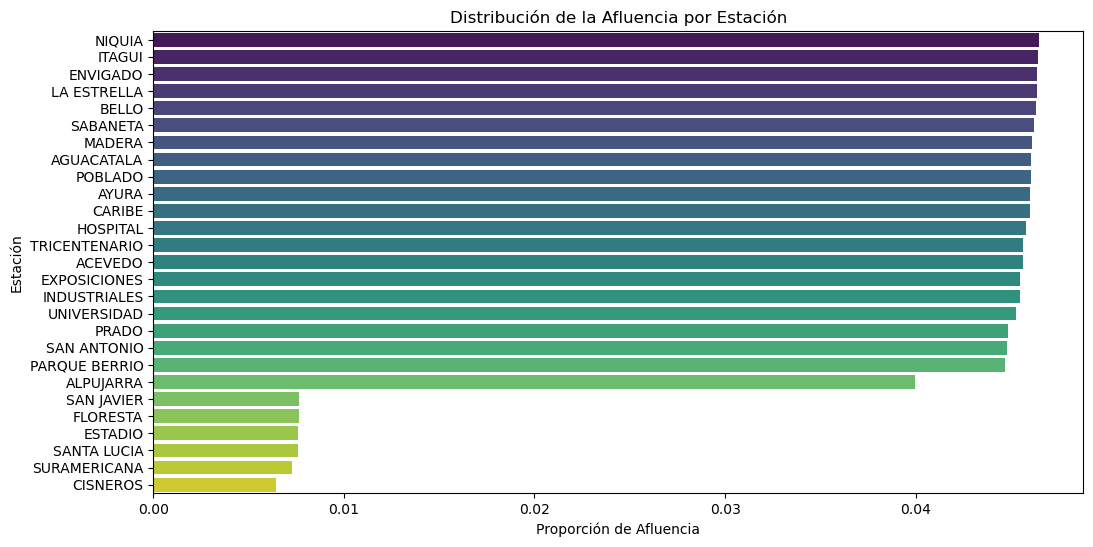

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar las estaciones por proporción de afluencia
afluencia_promedio = afluencia_promedio.sort_values(by="Proporcion_Estacion", ascending=False)

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x="Proporcion_Estacion", y="EO", data=afluencia_promedio, palette="viridis")

plt.xlabel("Proporción de Afluencia")
plt.ylabel("Estación")
plt.title("Distribución de la Afluencia por Estación")
plt.show()


/tmp/ipykernel_15950/3158574250.py:3: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  plt.pie(top_5["Proporcion_Estacion"], labels=top_5["EO"], autopct="%1.1f%%",


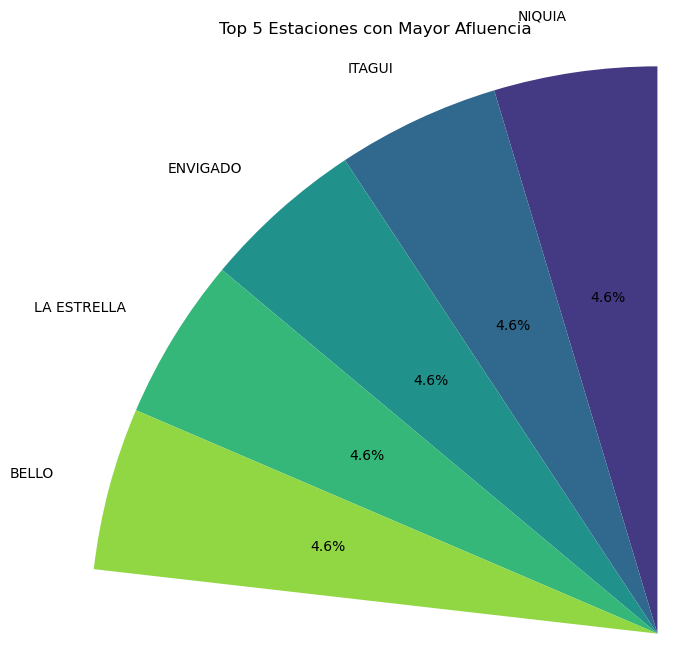

             EO  Proporcion_Estacion
16       NIQUIA             0.046456
13       ITAGUI             0.046386
7      ENVIGADO             0.046375
14  LA ESTRELLA             0.046350
4         BELLO             0.046291


In [11]:
top_5 = afluencia_promedio.sort_values(by="Proporcion_Estacion", ascending=False).head(5)
plt.figure(figsize=(8, 8))
plt.pie(top_5["Proporcion_Estacion"], labels=top_5["EO"], autopct="%1.1f%%", 
        startangle=90, colors=sns.color_palette("viridis", len(top_5)))

plt.title("Top 5 Estaciones con Mayor Afluencia")
plt.axis("equal")  # Mantiene la forma circular
plt.show()
print(top_5[["EO", "Proporcion_Estacion"]])



In [16]:
# Asegúrate de convertir la columna 'fecha' al formato datetime
DIARIO['dia'] = pd.to_datetime(DIARIO['dia'], format='%d/%m/%Y')

# Extraer el año como entero
DIARIO['Año'] = DIARIO['dia'].dt.year

# Verificar el resultado
print(DIARIO[['dia', 'Año']].head())


         dia   Año
0 2019-01-01  2019
1 2019-01-02  2019
2 2019-01-03  2019
3 2019-01-04  2019
4 2019-01-05  2019


In [17]:
# Renombrar columnas del dataset DIARIO para asegurar la consistencia
DIARIO.rename(columns={'linea_Servicio': 'LINEA ORIGEN'}, inplace=True)
OD.rename(columns={'fecha_uso': 'Año'}, inplace=True)

print(DIARIO.head())
print(OD.head())

         dia LINEA ORIGEN     Hora  Afluencia   Año  mes  dia_semana  \
0 2019-01-01            A  4:00:00       14.0  2019    1           1   
1 2019-01-02            A  4:00:00     8890.0  2019    1           2   
2 2019-01-03            A  4:00:00     9879.0  2019    1           3   
3 2019-01-04            A  4:00:00     9829.0  2019    1           4   
4 2019-01-05            A  4:00:00     8658.0  2019    1           5   

   es_festivo  
0           1  
1           0  
2           0  
3           0  
4           0  
    Año                  OD       EO          ED LINEA ORIGEN LINEA DESTINO  \
0  2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A             A   
1  2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A             A   
2  2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A             A   
3  2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A             A   
4  2024  ACEVEDO-AGUACATALA  ACEVEDO  AGUACATALA            A             A 

In [18]:
# Extraer el mes y el día de la semana
DIARIO['mes'] = DIARIO['dia'].dt.month
DIARIO['dia_semana'] = DIARIO['dia'].dt.weekday  # 0 = lunes, 1 = martes, ..., 6 = domingo
print(DIARIO.head())

         dia LINEA ORIGEN     Hora  Afluencia   Año  mes  dia_semana  \
0 2019-01-01            A  4:00:00       14.0  2019    1           1   
1 2019-01-02            A  4:00:00     8890.0  2019    1           2   
2 2019-01-03            A  4:00:00     9879.0  2019    1           3   
3 2019-01-04            A  4:00:00     9829.0  2019    1           4   
4 2019-01-05            A  4:00:00     8658.0  2019    1           5   

   es_festivo  
0           1  
1           0  
2           0  
3           0  
4           0  


In [19]:
festivos = ['2019-01-01', '2019-01-07','2019-03-25','2019-04-18'
           ,'2019-04-19','2019-05-01','2019-06-03','2019-06-24'
           ,'2019-07-01','2019-07-20','2019-08-07','2019-08-19'
           ,'2019-10-14','2019-11-11','2019-12-08','2019-12-25'
           ,'2020-01-01','2020-01-06','2020-03-23','2020-04-09'
           ,'2020-04-10','2020-05-01','2020-05-25','2019-06-15'
           ,'2020-06-22','2020-06-29','2020-07-20','2019-08-07'
           ,'2020-08-17','2020-10-12','2020-11-02','2020-11-16'
           ,'2020-12-08','2020-12-25','2021-01-01','2021-01-11'
           ,'2021-03-22','2021-04-01','2021-04-02','2021-05-01'
           ,'2021-05-17','2021-06-07','2021-06-14','2021-07-05'
           ,'2021-07-20','2021-08-07','2021-08-16','2021-10-18'
           ,'2021-11-01','2021-11-15','2021-12-08','2021-12-25'
           ,'2022-01-01','2022-01-06','2022-03-19','2022-04-14'
           ,'2022-04-15','2022-05-01','2022-05-16','2022-06-20'
           ,'2022-06-27','2022-07-20','2022-08-07','2022-08-15'
           ,'2022-10-12','2022-11-01','2022-11-11','2022-12-08'
           ,'2022-12-25','2023-01-01','2023-01-06','2023-03-20'
           ,'2023-04-06','2023-04-07','2023-05-01','2023-05-15'
           ,'2023-06-19','2023-06-26','2023-07-20','2023-08-07'
           ,'2023-08-15','2023-10-12','2023-11-01','2023-11-11'
           ,'2023-12-08','2023-12-25','2024-01-01','2024-01-08'
           ,'2024-03-25','2024-03-28','2024-03-29','2024-05-01'
           ,'2024-05-13','2024-06-03','2024-06-10','2024-07-01'
           ,'2024-07-20','2024-08-07','2024-08-15','2024-10-12'
           ,'2024-11-02','2024-11-16','2024-12-08','2024-12-25']  
festivos = pd.to_datetime(festivos)  # Convertir a datetime
# Convertir a un DataFrame o Series para visualizarlo
festivos_df = pd.Series(festivos,name='dia')

festivos_df = pd.DataFrame(festivos, columns=['dia'])

# Mostrar los primeros elementos
print(festivos_df.head())


         dia
0 2019-01-01
1 2019-01-07
2 2019-03-25
3 2019-04-18
4 2019-04-19


In [20]:
# Creamos una columna booleana que indica si el día es festivo o no
DIARIO = pd.merge(DIARIO, festivos_df, left_on='dia', right_on='dia', how='left')

DIARIO['es_festivo'] = DIARIO['dia'].isin(festivos_df['dia']).astype(int)  # Si es festivo será 1, si no será 0

# Mostrar los primeros elementos del DataFrame
print(DIARIO.head())


         dia LINEA ORIGEN     Hora  Afluencia   Año  mes  dia_semana  \
0 2019-01-01            A  4:00:00       14.0  2019    1           1   
1 2019-01-02            A  4:00:00     8890.0  2019    1           2   
2 2019-01-03            A  4:00:00     9879.0  2019    1           3   
3 2019-01-04            A  4:00:00     9829.0  2019    1           4   
4 2019-01-05            A  4:00:00     8658.0  2019    1           5   

   es_festivo  
0           1  
1           0  
2           0  
3           0  
4           0  


In [21]:
# Crear el One-Hot Encoding para los días de la semana
dias_semana_ohe = pd.get_dummies(DIARIO['dia_semana'], prefix='dia_semana')

# Unir el One-Hot Encoding al DataFrame original
DIARIO = pd.concat([DIARIO, dias_semana_ohe], axis=1)

# Mostrar los primeros elementos del DataFrame actualizado
print(DIARIO.head())


         dia LINEA ORIGEN     Hora  Afluencia   Año  mes  dia_semana  \
0 2019-01-01            A  4:00:00       14.0  2019    1           1   
1 2019-01-02            A  4:00:00     8890.0  2019    1           2   
2 2019-01-03            A  4:00:00     9879.0  2019    1           3   
3 2019-01-04            A  4:00:00     9829.0  2019    1           4   
4 2019-01-05            A  4:00:00     8658.0  2019    1           5   

   es_festivo  dia_semana_0  dia_semana_1  dia_semana_2  dia_semana_3  \
0           1             0             1             0             0   
1           0             0             0             1             0   
2           0             0             0             0             1   
3           0             0             0             0             0   
4           0             0             0             0             0   

   dia_semana_4  dia_semana_5  dia_semana_6  
0             0             0             0  
1             0             0       

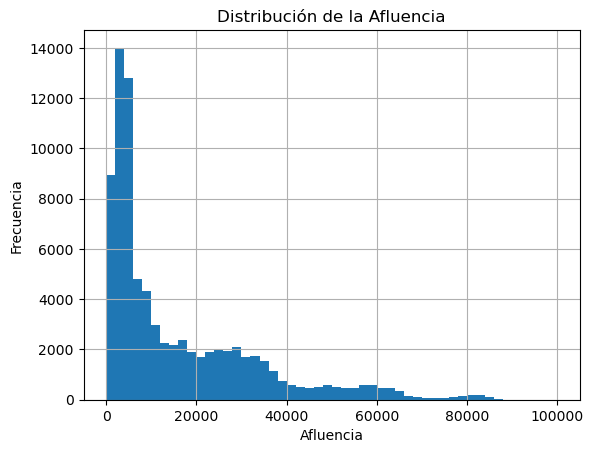

In [22]:
import matplotlib.pyplot as plt

# Mostrar el histograma de la columna 'Afluencia'
DIARIO['Afluencia'].hist(bins=50,range=(0, 100000))
plt.xlabel('Afluencia')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Afluencia')
plt.show()


In [23]:
# Cálculo de la media
media_afluencia = DIARIO['Afluencia'].mean()

# Cálculo de la desviación estándar
desviacion_afluencia = DIARIO['Afluencia'].std()

print(f"Media: {media_afluencia}")
print(f"Desviación estándar: {desviacion_afluencia}")


Media: 15790.016457292646
Desviación estándar: 17313.108174141766


In [24]:
from sklearn.preprocessing import MinMaxScaler

# Crear un objeto MinMaxScaler
scaler = MinMaxScaler()

# Aplicar normalización a la columna 'Afluencia'
DIARIO['afluencia_normalizada'] = scaler.fit_transform(DIARIO[['Afluencia']])


In [25]:
from sklearn.preprocessing import StandardScaler

# Crear un objeto StandardScaler
scaler = StandardScaler()

# Aplicar estandarización a la columna 'Afluencia'
DIARIO['afluencia_estandarizada'] = scaler.fit_transform(DIARIO[['Afluencia']])


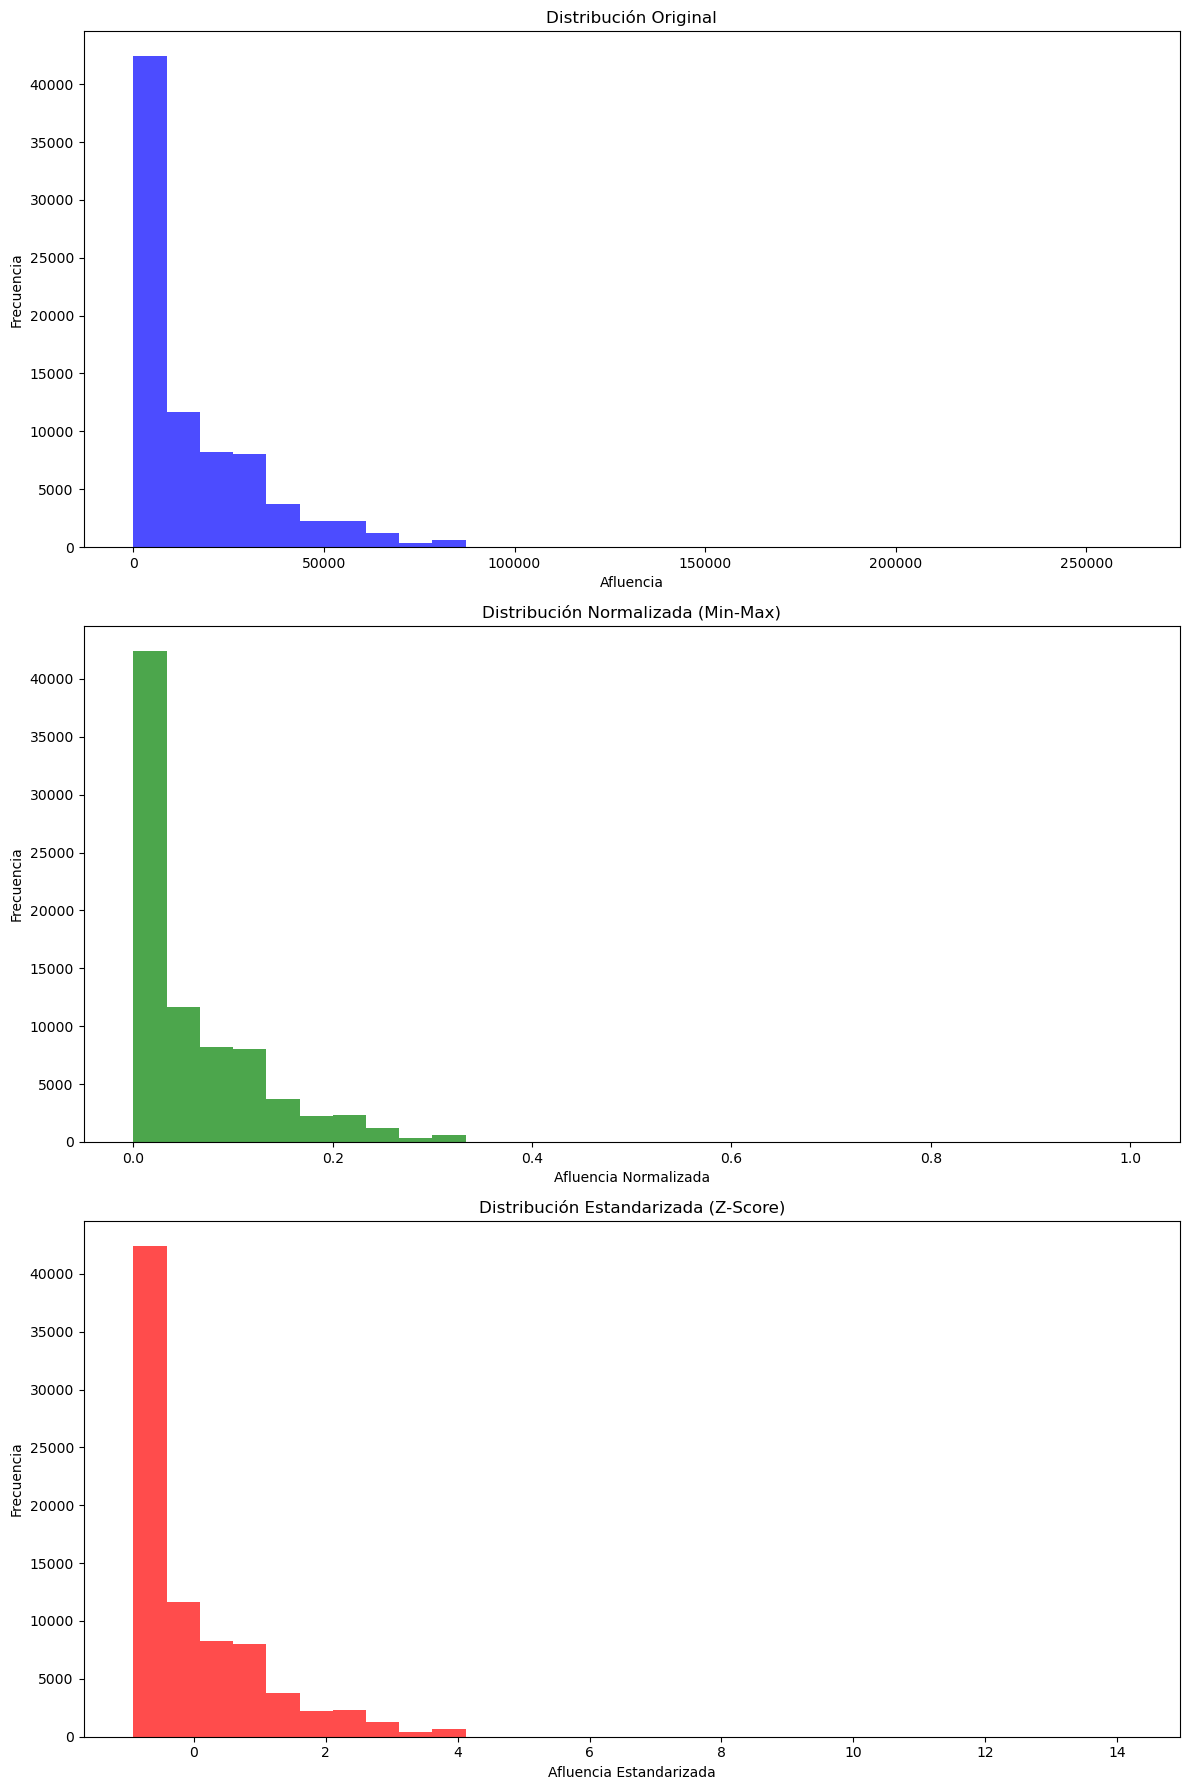

In [26]:
import matplotlib.pyplot as plt

# Crear subgráficos para cada transformación
plt.figure(figsize=(12, 18))

# Gráfico de los datos originales
plt.subplot(3, 1, 1)
plt.hist(DIARIO['Afluencia'], bins=30, color='blue', alpha=0.7)
plt.title('Distribución Original')
plt.xlabel('Afluencia')
plt.ylabel('Frecuencia')

# Gráfico de los datos normalizados
plt.subplot(3, 1, 2)
plt.hist(DIARIO['afluencia_normalizada'], bins=30, color='green', alpha=0.7)
plt.title('Distribución Normalizada (Min-Max)')
plt.xlabel('Afluencia Normalizada')
plt.ylabel('Frecuencia')

# Gráfico de los datos estandarizados
plt.subplot(3, 1, 3)
plt.hist(DIARIO['afluencia_estandarizada'], bins=30, color='red', alpha=0.7)
plt.title('Distribución Estandarizada (Z-Score)')
plt.xlabel('Afluencia Estandarizada')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


In [27]:
import numpy as np
# Comprobar valores nulos, infinitos o problemas
DIARIO = DIARIO.dropna(subset=['Afluencia'])
print(DIARIO['Afluencia'].describe())
print(DIARIO['Afluencia'].isnull().sum())  # Valores nulos
print(np.isinf(DIARIO['Afluencia']).sum())  # Valores infinitos


count     80876.000000
mean      15790.016457
std       17313.108174
min           1.000000
25%        3557.750000
50%        7946.000000
75%       24498.250000
max      261549.000000
Name: Afluencia, dtype: float64
0
0


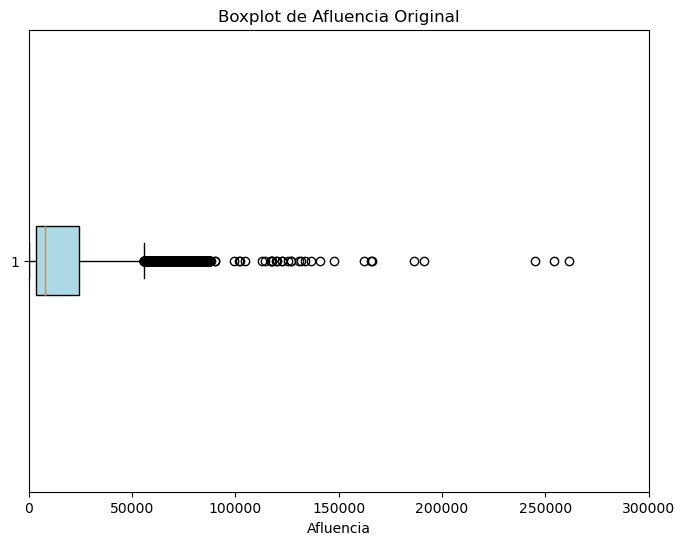

In [28]:
plt.figure(figsize=(8, 6))
plt.boxplot(DIARIO['Afluencia'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title("Boxplot de Afluencia Original")
plt.xlabel("Afluencia")
plt.xlim(0, 300000)  # Ajusta el rango
plt.show()


In [29]:
print(DIARIO['Hora'].dtypes)
print(DIARIO['Hora'].unique())  # Para identificar valores no numéricos

object
['4:00:00' '5:00:00' '6:00:00' '7:00:00' '8:00:00' '9:00:00' '10:00:00'
 '11:00:00' '12:00:00' '13:00:00' '14:00:00' '15:00:00' '16:00:00'
 '17:00:00' '18:00:00' '19:00:00' '20:00:00' '21:00:00' '22:00:00']


In [30]:
DIARIO['Hora'] = pd.to_datetime(DIARIO['Hora'], format='%H:%M:%S')
DIARIO['Hora'] = DIARIO['Hora'].dt.hour

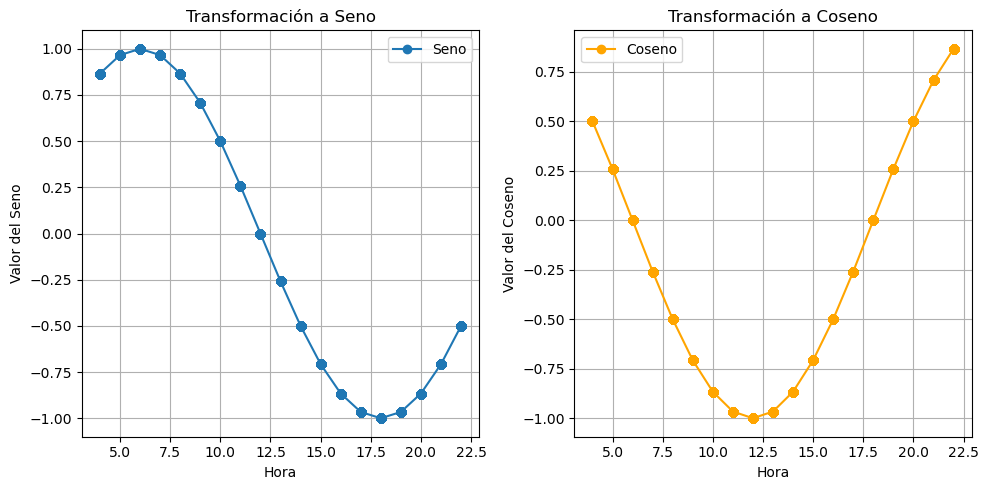

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# las horas están en un rango de 0 a 23
DIARIO['Hora_Seno'] = np.sin(2 * np.pi * DIARIO['Hora'] / 24)
DIARIO['Hora_Coseno'] = np.cos(2 * np.pi * DIARIO['Hora'] / 24)

# Graficar para visualizar
plt.figure(figsize=(10, 5))

# Seno
plt.subplot(1, 2, 1)
plt.plot(DIARIO['Hora'], DIARIO['Hora_Seno'], 'o-', label='Seno')
plt.title('Transformación a Seno')
plt.xlabel('Hora')
plt.ylabel('Valor del Seno')
plt.grid(True)
plt.legend()

# Coseno
plt.subplot(1, 2, 2)
plt.plot(DIARIO['Hora'], DIARIO['Hora_Coseno'], 'o-', label='Coseno', color='orange')
plt.title('Transformación a Coseno')
plt.xlabel('Hora')
plt.ylabel('Valor del Coseno')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [32]:
print(DIARIO.head())


         dia LINEA ORIGEN  Hora  Afluencia   Año  mes  dia_semana  es_festivo  \
0 2019-01-01            A     4       14.0  2019    1           1           1   
1 2019-01-02            A     4     8890.0  2019    1           2           0   
2 2019-01-03            A     4     9879.0  2019    1           3           0   
3 2019-01-04            A     4     9829.0  2019    1           4           0   
4 2019-01-05            A     4     8658.0  2019    1           5           0   

   dia_semana_0  dia_semana_1  dia_semana_2  dia_semana_3  dia_semana_4  \
0             0             1             0             0             0   
1             0             0             1             0             0   
2             0             0             0             1             0   
3             0             0             0             0             1   
4             0             0             0             0             0   

   dia_semana_5  dia_semana_6  afluencia_normalizada  afluenci

In [33]:
print(DIARIO.dtypes)

dia                        datetime64[ns]
LINEA ORIGEN                       object
Hora                                int64
Afluencia                         float64
Año                                 int64
mes                                 int64
dia_semana                          int64
es_festivo                          int64
dia_semana_0                        uint8
dia_semana_1                        uint8
dia_semana_2                        uint8
dia_semana_3                        uint8
dia_semana_4                        uint8
dia_semana_5                        uint8
dia_semana_6                        uint8
afluencia_normalizada             float64
afluencia_estandarizada           float64
Hora_Seno                         float64
Hora_Coseno                       float64
dtype: object


In [34]:
# Convertir LINEA ORIGEN a una variable binaria
DIARIO['LINEA ORIGEN'] = DIARIO['LINEA ORIGEN'].map({'A': 0, 'B': 1})
print(DIARIO.dtypes)

dia                        datetime64[ns]
LINEA ORIGEN                        int64
Hora                                int64
Afluencia                         float64
Año                                 int64
mes                                 int64
dia_semana                          int64
es_festivo                          int64
dia_semana_0                        uint8
dia_semana_1                        uint8
dia_semana_2                        uint8
dia_semana_3                        uint8
dia_semana_4                        uint8
dia_semana_5                        uint8
dia_semana_6                        uint8
afluencia_normalizada             float64
afluencia_estandarizada           float64
Hora_Seno                         float64
Hora_Coseno                       float64
dtype: object


In [35]:
# Ordenar los datos cronológicamente (asegurarse de que 'dia' esté en formato datetime)
df = DIARIO.sort_values(by=['dia','Hora']).reset_index(drop=True)
df= df.drop(columns=['dia_semana_0', 'dia_semana_1', 'dia_semana_2', 'dia_semana_3', 
        'dia_semana_4', 'dia_semana_5', 'dia_semana_6','Afluencia','Hora_Seno','Hora_Coseno'])
print (df.head())
print(df.shape)

         dia  LINEA ORIGEN  Hora   Año  mes  dia_semana  es_festivo  \
0 2019-01-01             0     4  2019    1           1           1   
1 2019-01-01             0     5  2019    1           1           1   
2 2019-01-01             1     5  2019    1           1           1   
3 2019-01-01             0     6  2019    1           1           1   
4 2019-01-01             1     6  2019    1           1           1   

   afluencia_normalizada  afluencia_estandarizada  
0               0.000050                -0.911224  
1               0.017408                -0.648993  
2               0.002588                -0.872871  
3               0.021774                -0.583031  
4               0.003181                -0.863918  
(80876, 9)


In [36]:
df['Semana'] = df['dia'].dt.isocalendar().week

# Mostrar las primeras filas del DataFrame agrupado
print(df.head())

print(df.shape)

print(df['Año'].unique())

         dia  LINEA ORIGEN  Hora   Año  mes  dia_semana  es_festivo  \
0 2019-01-01             0     4  2019    1           1           1   
1 2019-01-01             0     5  2019    1           1           1   
2 2019-01-01             1     5  2019    1           1           1   
3 2019-01-01             0     6  2019    1           1           1   
4 2019-01-01             1     6  2019    1           1           1   

   afluencia_normalizada  afluencia_estandarizada  Semana  
0               0.000050                -0.911224       1  
1               0.017408                -0.648993       1  
2               0.002588                -0.872871       1  
3               0.021774                -0.583031       1  
4               0.003181                -0.863918       1  
(80876, 10)
[2019 2020 2021 2022 2023 2024]


In [37]:
# Filtrar por horas pico
df_pico = df[
    ((df["Hora"] >= 4) & (df["Hora"] <= 8)) |  # Mañana: 4:30 AM - 8:15 AM
    ((df["Hora"] >= 15) & (df["Hora"] <= 19))  # Tarde: 3:15 PM - 7:15 PM
]

# Ver cuántos datos quedan
print(df_pico.shape)
print(df_pico.head())

(42577, 10)
         dia  LINEA ORIGEN  Hora   Año  mes  dia_semana  es_festivo  \
0 2019-01-01             0     4  2019    1           1           1   
1 2019-01-01             0     5  2019    1           1           1   
2 2019-01-01             1     5  2019    1           1           1   
3 2019-01-01             0     6  2019    1           1           1   
4 2019-01-01             1     6  2019    1           1           1   

   afluencia_normalizada  afluencia_estandarizada  Semana  
0               0.000050                -0.911224       1  
1               0.017408                -0.648993       1  
2               0.002588                -0.872871       1  
3               0.021774                -0.583031       1  
4               0.003181                -0.863918       1  


In [38]:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 62.6 MB/s eta 0:00:00ta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.19.5
    Uninstalling numpy-1.19.5:
      Successfully uninstalled numpy-1.19.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mgwr 2.2.1 requires spglm>=1.0.6, but you have spglm 0.0.0 which is incompatible.
momepy 0.0.0 requires shapely>=2, but you have shapely 1.8.2 which is incompatible.
pointpats 2.3.0 requires scipy>=1.8.0, but you have scipy 1.6.3 which is incompatible.
pysal 2.7.0 requires momepy>=0.5.3, but you have momepy 0.0.0 which is incompatible.
pysal 2.7.0 requires spglm>=1.0.8, but you have spglm 0.0.0 which is incompatible.
pysal 2.7.0 requires spreg>=1.2.4, but you have spreg 0.0.0 which is incompatible.
spag

In [39]:
import pandas as pd
import statsmodels.api as sm

# Agrupar por semana sumando la afluencia
df_semanal_pico = df_pico.groupby(pd.Grouper(key="dia", freq="W"))["afluencia_normalizada"].sum()

# Verificar el índice
print(df_semanal_pico.head())

# Ajustar SARIMA
p, d, q = 3, 0, 3  # Puedes ajustar estos valores con Grid Search o prueba y error
P, D, Q, s = 3, 0, 3, 52  # 52 semanas en un año

modelo_sarima = sm.tsa.statespace.SARIMAX(df_semanal_pico, 
                                          order=(p, d, q), 
                                          seasonal_order=(P, D, Q, s),
                                          enforce_stationarity=False, 
                                          enforce_invertibility=False)
resultado = modelo_sarima.fit()

# Hacer predicciones
predicciones = resultado.forecast(steps=10)  # Predecir las próximas 10 semanas
print(predicciones)


dia
2019-01-06     6.816695
2019-01-13     9.564099
2019-01-20    11.945314
2019-01-27    12.104749
2019-02-03    12.203332
Freq: W-SUN, Name: afluencia_normalizada, dtype: float64


/opt/conda/miniconda3/lib/python3.8/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           13     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.37877D-01    |proj g|=  8.14325D-01

At iterate    5    f=  8.20562D-01    |proj g|=  4.12780D+00

At iterate   10    f=  7.76984D-01    |proj g|=  2.88085D-01

At iterate   15    f=  7.76847D-01    |proj g|=  1.13052D+00

At iterate   20    f=  7.65608D-01    |proj g|=  2.75315D+00

At iterate   25    f=  7.56492D-01    |proj g|=  1.01468D+00

At iterate   30    f=  7.54500D-01    |proj g|=  2.61972D-01

At iterate   35    f=  7.49286D-01    |proj g|=  4.99266D-01

At iterate   40    f=  7.45595D-01    |proj g|=  6.94930D-02

At iterate   45    f=  7.42323D-01    |proj g|=  3.32398D+00

At iterate   50    f=  7.34676D-01    |proj g|=  1.67806D+00

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/opt/conda/miniconda3/lib/python3.8/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2024-11-10    11.815824
2024-11-17    12.126828
2024-11-24    11.925221
2024-12-01    12.237842
2024-12-08    11.936163
2024-12-15    12.551459
2024-12-22    11.783982
2024-12-29    11.484820
2025-01-05    10.942823
2025-01-12    11.498670
Freq: W-SUN, Name: predicted_mean, dtype: float64


In [40]:
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(df_semanal_pico)
print(f"p-valor: {resultado_adf[1]}")

if resultado_adf[1] < 0.05:
    print("La serie es estacionaria")
else:
    print("La serie no es estacionaria, prueba con diferenciación")


p-valor: 0.011122220223640972
La serie es estacionaria


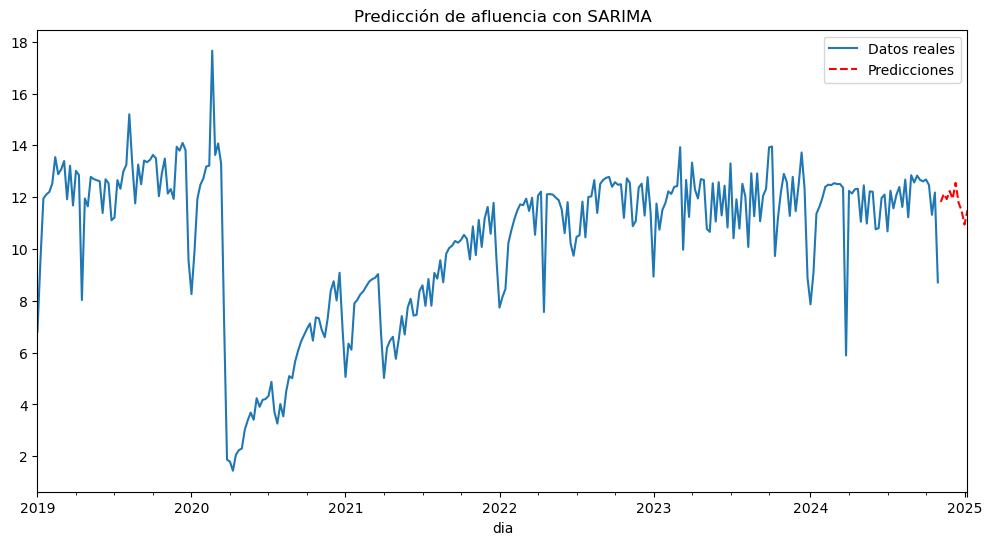

In [41]:
import matplotlib.pyplot as plt

# Graficar la serie original
df_semanal_pico.plot(label="Datos reales", figsize=(12,6))

# Graficar las predicciones
predicciones.plot(label="Predicciones", linestyle="dashed", color="red")

plt.legend()
plt.title("Predicción de afluencia con SARIMA")
plt.show()


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_real = df_semanal_pico[-10:]  # Últimos 10 valores reales
y_pred = predicciones[:10]  # Primeros 10 valores predichos

mae = mean_absolute_error(y_real, y_pred)
rmse = mean_squared_error(y_real, y_pred, squared=False)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")


MAE: 0.848517838164214
RMSE: 1.119970193104985


In [43]:
media_afluencia = df_semanal_pico.mean()
print(f"Media de afluencia: {media_afluencia}")
print(f"RMSE en relación con la media: {rmse / media_afluencia * 100:.2f}%")


Media de afluencia: 10.432625713689013
RMSE en relación con la media: 10.74%


In [44]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Cargar y normalizar los datos
scaler = MinMaxScaler()
data = df_pico["afluencia_normalizada"].values.reshape(-1, 1)
data_scaled = scaler.fit_transform(data)

# 2. Crear secuencias de tiempo
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10  # Ventana temporal de 10 semanas
X, y = create_sequences(data_scaled, seq_length)

# 3. Dividir en entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# 4. Construcción del modelo LSTM
model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# 5. Predicción
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test)

# 6. Evaluación
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")




ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# 7. Gráfica de predicciones
plt.figure(figsize=(12, 6))
plt.plot(df_pico.index[-len(y_test):], y_test, label="Datos reales")
plt.plot(df_pico.index[-len(y_pred):], y_pred, label="Predicción LSTM", linestyle="dashed")
plt.legend()
plt.title("Predicción de afluencia con LSTM")
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# 1. Calcular los residuos (errores)
residuos = y_test - y_pred

# 2. Crear la figura
plt.figure(figsize=(10, 5))

# 3. Graficar los residuos
plt.plot(residuos, marker='o', linestyle='', alpha=0.5, label="Residuos")

# 4. Línea de referencia en y=0
plt.axhline(y=0, color='r', linestyle='--', label="Línea base (0)")

# 5. Personalización del gráfico
plt.xlabel("Índice de la muestra")
plt.ylabel("Error (y_test - y_pred)")
plt.title("Gráfica de residuos del modelo LSTM")
plt.legend()
plt.grid(True)

# 6. Mostrar la gráfica
plt.show()


In [ ]:
# Predicción de la afluencia futura
last_seq = X[-1]  # Última secuencia conocida
predictions = []

for _ in range(10):  # Predecimos 10 semanas en el futuro
    pred = model.predict(np.expand_dims(last_seq, axis=0))[0, 0]
    predictions.append(pred)
    last_seq = np.roll(last_seq, -1)
    last_seq[-1] = pred  # Agregar la nueva predicción a la secuencia

# Desnormalizar los valores predichos
predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Crear un índice de fechas para la predicción
future_dates = pd.date_range(start=df_pico.index[-1], periods=11, freq="W")[1:]
pred_df = pd.DataFrame({"Fecha": future_dates, "Pred_Afluencia": predictions.flatten()})
print(pred_df)


In [ ]:
plt.figure(figsize=(12,6))

# Gráfica de la serie original
plt.plot(df_semanal.index, df_semanal["afluencia_normalizada"], label="Real", color="blue")

# Predicciones LSTM
plt.plot(future_dates, predictions, label="LSTM Predicción", color="red")

# Predicciones SARIMA
plt.plot(sarima_preds.index, sarima_preds.values, label="SARIMA Predicción", color="green")

plt.legend()
plt.title("Comparación de Predicciones: LSTM vs SARIMA")
plt.show()


modelo prueba 1 sin ventana de tiempo definida

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Características (features) con Hora_Seno y Hora_Coseno
X = DIARIO[['Año', 'mes', 'dia_semana_0', 'dia_semana_1', 'dia_semana_2', 'dia_semana_3', 
        'dia_semana_4', 'dia_semana_5', 'dia_semana_6', 'es_festivo', 'Hora_Seno', 
        'Hora_Coseno','LINEA ORIGEN']]

# Variable objetivo (target)
y = DIARIO['afluencia_estandarizada']

# Dividir en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarización de las características para mejorar el rendimiento del modelo
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import matplotlib.pyplot as plt

# Reshape los datos para que sean compatibles con LSTM
# Convierte los datos en [samples, timesteps, features]
X_train_reshaped = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))


# Dimensiones de entrada (número de características)
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])

# Definir el modelo
model = Sequential()

# Capa LSTM para modelar secuencias temporales
model.add(LSTM(64, activation='tanh', return_sequences=False, input_shape=input_shape))

# Capa densa con activación ReLU
model.add(Dense(64, activation='relu'))

# Capa de salida (sin activación, ya que buscamos regresión)
model.add(Dense(1, activation='linear'))

# Compilar el modelo con el optimizador Adam y la métrica MSE
model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError(), metrics=['mse'])

# Resumen del modelo
model.summary()

# Entrenar el modelo
history = model.fit(
    X_train_reshaped,
    y_train,
    validation_data=(X_test_reshaped, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Graficar la pérdida (loss) vs época
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid()
plt.show()



In [ ]:
# Graficar la métrica (MSE) vs épocas
plt.figure(figsize=(8, 6))
plt.plot(history.history['mse'], label='MSE de entrenamiento')
plt.plot(history.history['val_mse'], label='MSE de validación')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.title('MSE vs Épocas')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Asegúrate de que los datos tengan la forma esperada (n_samples, timesteps, n_features)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
# Predicciones
y_pred = model.predict(X_test)

# Gráfico de residuos
residuos = y_test - y_pred.flatten()
plt.figure(figsize=(8, 6))
plt.hist(residuos, bins=20, color='purple', alpha=0.7)
plt.xlabel('Error (Residuos)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuos, alpha=0.5, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Reales")
plt.ylabel("Residuos")
plt.title("Gráfico de Residuos vs Valores Reales")
plt.show()


In [ ]:
print("Media de los residuos:", np.mean(residuos))
print("Desviación estándar de los residuos:", np.std(residuos))
print("Valores mínimos y máximos de los residuos:", np.min(residuos), np.max(residuos))


In [ ]:
outliers = np.where(np.abs(residuos) > 2*np.std(residuos))
print("Índices de outliers:", outliers)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el gráfico de caja y bigotes
plt.figure(figsize=(8, 6))
sns.boxplot(x=residuos, color='purple')

# Personalizar el gráfico
plt.title('Boxplot de los Residuos', fontsize=16)
plt.xlabel('Residuos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()
